In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_dir = Path(r"C:\Users\34689\Desktop\Glole\U\masterus\percep")

summary_path = project_dir / "outputs" / "plots" / "real" / "real_experiments_summary.csv"

summary_df = pd.read_csv(summary_path)

summary_df

,scenario,method,detections,mean_displacement,median_displacement,p95_displacement,max_displacement,mean_area,mean_points_per_frame
0,real_normal,frame_difference,17,41.313270,24.149303,93.210050,176.025566,28380.823529,NaN
1,real_normal,lucas_kanade,269,3.193416,2.275785,5.426818,211.573074,NaN,8.899628
2,real_noisy,frame_difference,42,52.963509,36.013886,220.009091,279.401145,7400.226190,NaN
3,real_noisy,lucas_kanade,403,3.455172,3.052055,7.478082,34.603447,NaN,49.337469
4,real_light_change,frame_difference,14,110.512790,13.416408,352.432972,352.432972,212029.642857,NaN
5,real_light_change,lucas_kanade,68,10.686628,2.548083,10.012781,849.048950,NaN,15.926471
6,real_fast,frame_difference,88,59.296637,18.248288,231.397151,764.147237,9376.511364,NaN
7,real_fast,lucas_kanade,254,6.922899,2.765483,20.543942,643.266296,NaN,9.074803


In [ ]:
def get_condition(scenario_name):
    if "normal" in scenario_name:
        return "Normal"
    if "noisy" in scenario_name:
        return "Noisy"
    if "light_change" in scenario_name:
        return "Light change"
    if "fast" in scenario_name:
        return "Fast motion"
    return "Other"


condition_order = [
    "Normal",
    "Noisy",
    "Light change",
    "Fast motion",
]

method_labels = {
    "frame_difference": "Frame difference",
    "lucas_kanade": "Lucas-Kanade",
}

summary_df["condition"] = summary_df["scenario"].apply(get_condition)

summary_df["condition"] = pd.Categorical(
    summary_df["condition"],
    categories=condition_order,
    ordered=True
)

summary_df["method_label"] = summary_df["method"].map(method_labels)

summary_df = summary_df.sort_values(["condition", "scenario", "method"])

summary_df

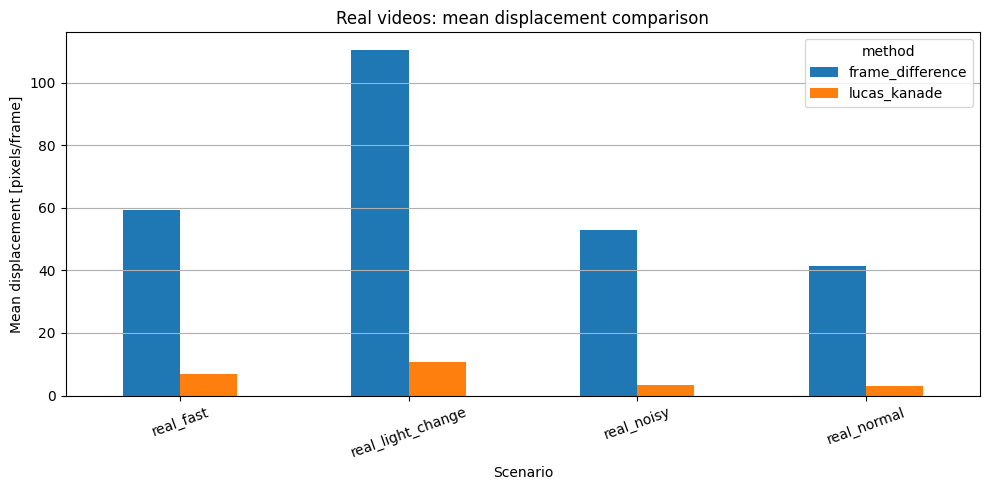

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_mean_displacement.png


In [11]:
mean_disp_plot = project_dir / "outputs" / "plots" / "real" / "real_mean_displacement.png"

pivot_mean = summary_df.pivot(
    index="scenario",
    columns="method",
    values="mean_displacement"
)

pivot_mean.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Mean displacement [pixels/frame]")
plt.xlabel("Scenario")
plt.title("Real videos: mean displacement comparison")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(mean_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", mean_disp_plot)

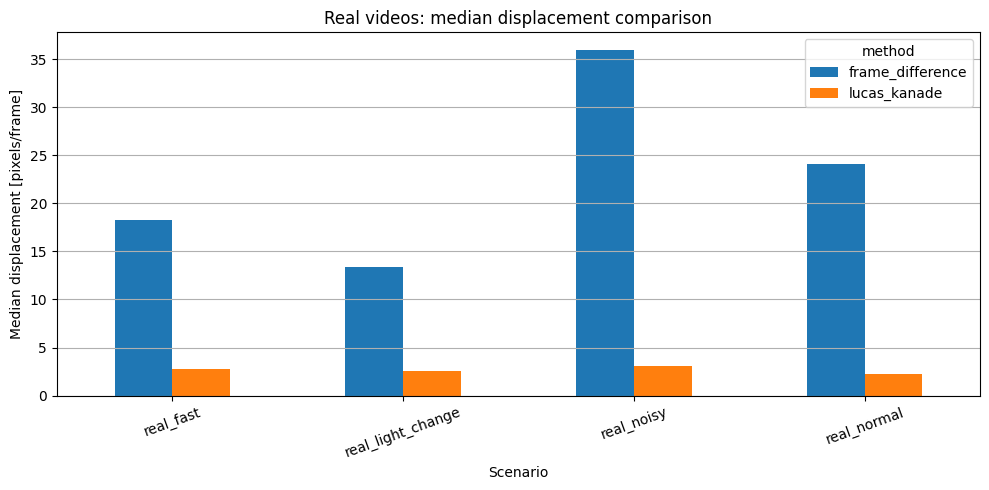

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_median_displacement.png


In [12]:
median_disp_plot = project_dir / "outputs" / "plots" / "real" / "real_median_displacement.png"

pivot_median = summary_df.pivot(
    index="scenario",
    columns="method",
    values="median_displacement"
)

pivot_median.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Median displacement [pixels/frame]")
plt.xlabel("Scenario")
plt.title("Real videos: median displacement comparison")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(median_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", median_disp_plot)

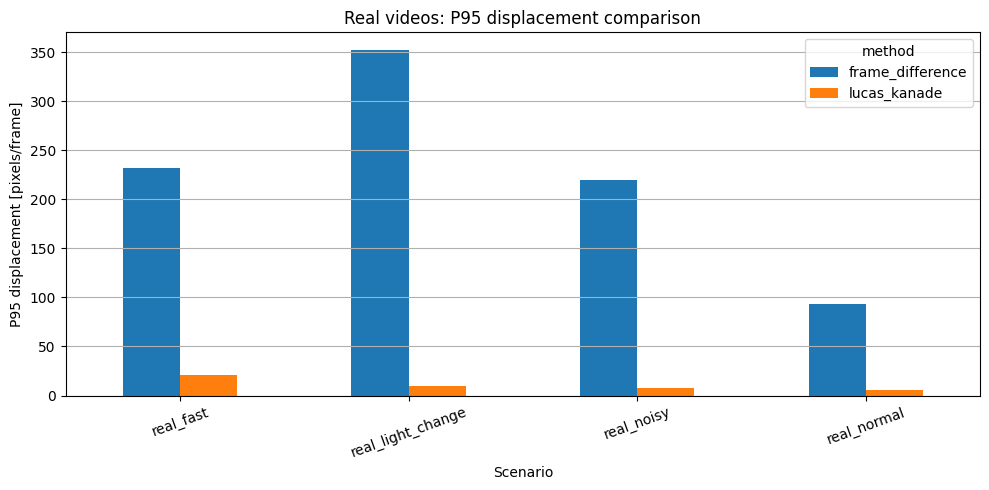

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_p95_displacement.png


In [13]:
p95_disp_plot = project_dir / "outputs" / "plots" / "real" / "real_p95_displacement.png"

pivot_p95 = summary_df.pivot(
    index="scenario",
    columns="method",
    values="p95_displacement"
)

pivot_p95.plot(kind="bar", figsize=(10, 5))

plt.ylabel("P95 displacement [pixels/frame]")
plt.xlabel("Scenario")
plt.title("Real videos: P95 displacement comparison")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(p95_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", p95_disp_plot)

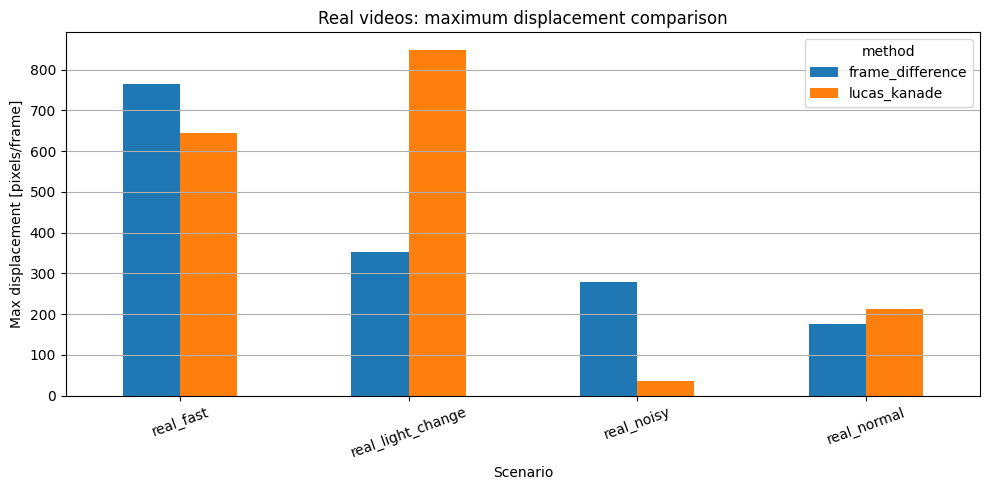

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_max_displacement.png


In [14]:
max_disp_plot = project_dir / "outputs" / "plots" / "real" / "real_max_displacement.png"

pivot_max = summary_df.pivot(
    index="scenario",
    columns="method",
    values="max_displacement"
)

pivot_max.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Max displacement [pixels/frame]")
plt.xlabel("Scenario")
plt.title("Real videos: maximum displacement comparison")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(max_disp_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", max_disp_plot)

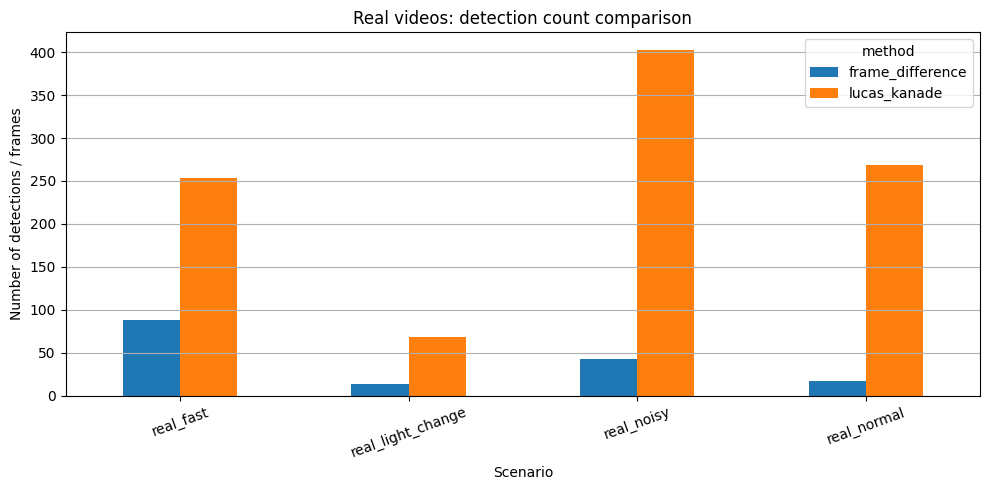

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_detections.png


In [15]:
detections_plot = project_dir / "outputs" / "plots" / "real" / "real_detections.png"

pivot_detections = summary_df.pivot(
    index="scenario",
    columns="method",
    values="detections"
)

pivot_detections.plot(kind="bar", figsize=(10, 5))

plt.ylabel("Number of detections / frames")
plt.xlabel("Scenario")
plt.title("Real videos: detection count comparison")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(detections_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", detections_plot)

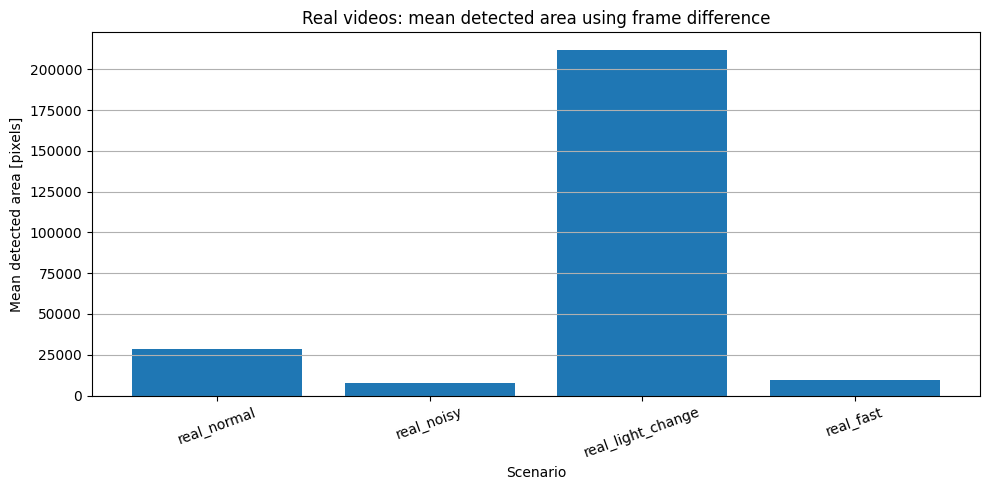

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_frame_difference_mean_area.png


In [16]:
area_plot = project_dir / "outputs" / "plots" / "real" / "real_frame_difference_mean_area.png"

frame_diff_df = summary_df[summary_df["method"] == "frame_difference"]

plt.figure(figsize=(10, 5))
plt.bar(frame_diff_df["scenario"], frame_diff_df["mean_area"])

plt.ylabel("Mean detected area [pixels]")
plt.xlabel("Scenario")
plt.title("Real videos: mean detected area using frame difference")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(area_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", area_plot)

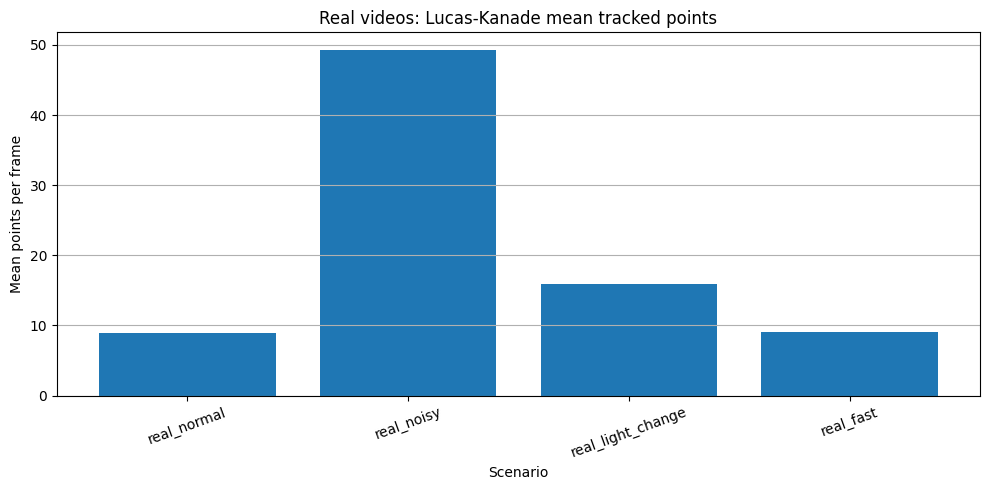

Saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\real\real_lucas_kanade_mean_points.png


In [17]:
points_plot = project_dir / "outputs" / "plots" / "real" / "real_lucas_kanade_mean_points.png"

lk_df = summary_df[summary_df["method"] == "lucas_kanade"]

plt.figure(figsize=(10, 5))
plt.bar(lk_df["scenario"], lk_df["mean_points_per_frame"])

plt.ylabel("Mean points per frame")
plt.xlabel("Scenario")
plt.title("Real videos: Lucas-Kanade mean tracked points")
plt.grid(axis="y")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(points_plot, dpi=150, bbox_inches="tight")
plt.show()

print("Saved at:", points_plot)

In [18]:
qualitative_summary = pd.DataFrame({
    "Scenario": [
        "real_normal",
        "real_noisy",
        "real_light_change",
        "real_fast",
    ],
    "Expected behavior": [
        "Controlled real case with normal object motion.",
        "Real video affected by image noise.",
        "Real video affected by illumination variation.",
        "Real video with faster object motion.",
    ],
    "Frame difference interpretation": [
        "Should detect the moving region, but may also include the hand or shadows.",
        "Can be affected by noisy pixel changes, although thresholding reduces part of the effect.",
        "Usually detects large regions because illumination changes are interpreted as motion.",
        "Can detect motion, but the detected region may become larger and less stable.",
    ],
    "Lucas-Kanade interpretation": [
        "Should track visual points on the object if it has enough texture.",
        "May track unstable points if noise creates false features.",
        "May lose stability if the appearance of points changes due to lighting.",
        "Can lose points or produce larger displacements if the motion between frames is too large.",
    ],
})

qualitative_summary

,Scenario,Expected behavior,Frame difference interpretation,Lucas-Kanade interpretation
0,real_normal,Controlled real case with normal object motion.,"Should detect the moving region, but may also ...",Should track visual points on the object if it...
1,real_noisy,Real video affected by image noise.,"Can be affected by noisy pixel changes, althou...",May track unstable points if noise creates fal...
2,real_light_change,Real video affected by illumination variation.,Usually detects large regions because illumina...,May lose stability if the appearance of points...
3,real_fast,Real video with faster object motion.,"Can detect motion, but the detected region may...",Can lose points or produce larger displacement...
